# Dimensionality Reduction

## PCA

* In Principal Component Analysis (PCA) we seek to take a data set like the one shown below and apply a transform to the data such that the new axes are **aligned with the maximal variance** of the data.
* This is basically just the same as doing regression by minimizing the square of the perpendicular distances to the new axes. Note that we haven't made any changes to the data, we have just defined new axes.
* The **first axis**, or principal component, is the direction of maximal variance. The **second principal component** is orthogonal to the first component and maximizes the residual variance

**This is why PCA enables dimensionality reduction**. We can use samples of measured data to train a data-driven basis that better explains it.

### Interpreting PCA

* The output eigenvectors are **ordered** by their associated eigenvalues
* The **eigenvalues** reflect the variance within each eigenvector, it measures exactly how much of the dataset's **total variance is stretched along its corresponding eigenvector** (Principal Component).
* The sum of the eigenvalues is total variance of the system.
* The projection of each spectrum onto the first few eigenspectra is a compression of the data

For example, we started with 4000 x 1000 floating point numbers. If we can explain nearly all of the variance with 8 eigenvectors, then we have reduced the problem to 4000 x 8 (the eigenspectra) + 8 x 1000 (the component weights) floating point numbers!

* How many components to keep? Cross validate with differnt numbers of components or use **scree plot** (which is a representation of eigenspectra, component number vs eigenvalue)
* PCA to reconstruct missing data. PCA learns a data-driven basis that is a linear combination of features that best explain the observed data. So it uses correlations across the features, which in this case are wavelengths. Those correlated features can be used to interpolate across or reconstruct missing data.

**Warning** A note of caution about the techniques you saw in the last lecture: PCA, NMF, and ICA are all linear methods.\
Astronomers will often try to derive physical insight from PCA eigenspectra or eigentimeseries, but there is **no physical reason for the data to be linearly and orthogonally separable**.\
Moreover, physical components are (generally) positive definite. So, PCA is great for dimensional reduction, but for doing physics there are generally better choices -> **non-linear** algorithm in sklearn.manifold

# The HR diagram

### Data visualization

In [154]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
import pandas as pd
df_stars = pd.read_csv("stars.csv")
df_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


In [155]:
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

le = LabelEncoder() 
df_stars['Star type'] = le.fit_transform(df_stars['Star type']) #convert strings into integers
labels = le.inverse_transform(df_stars['Star type']) #to check
class_names = le.classes_
print(class_names)


['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [156]:
ce = LabelEncoder()
df_stars['Star color'] = ce.fit_transform(df_stars['Star color'])
colors = ce.inverse_transform(df_stars['Star color'])
color_names = ce.classes_
print(color_names)

['Blue' 'Blue ' 'Blue White' 'Blue white' 'Blue white ' 'Blue-White'
 'Blue-white' 'Orange' 'Orange-Red' 'Pale yellow orange' 'Red' 'White'
 'White-Yellow' 'Whitish' 'Yellowish' 'Yellowish White' 'white'
 'yellow-white' 'yellowish']


In [157]:
sc = LabelEncoder()
df_stars['Spectral Class'] = sc.fit_transform(df_stars['Spectral Class'])
spectral_classes = sc.inverse_transform(df_stars['Spectral Class'])
spectral_class_names = sc.classes_
print(spectral_class_names)

['A' 'B' 'F' 'G' 'K' 'M' 'O']


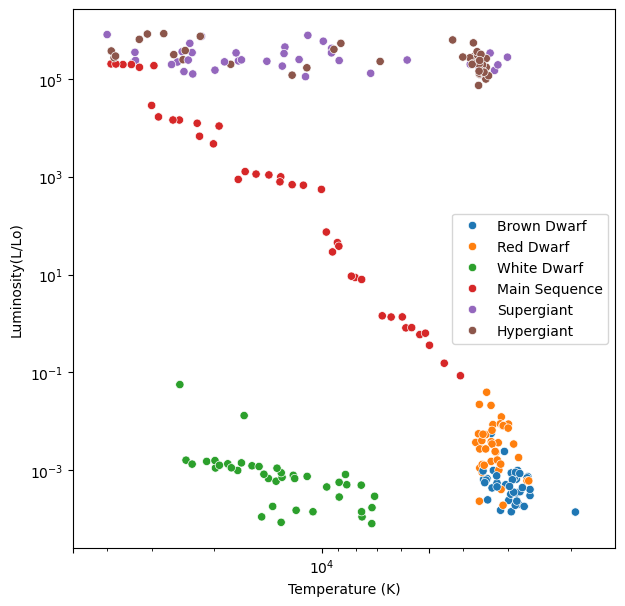

In [158]:
import seaborn as sns
fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels, palette='tab10')
plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

### PCA dimensionality reduction

Primo tentativo con dati non standardizzati e solver=randomizer \
Provato sia 2 che 4 componenti, stesso contenuto di info presente nella prima componente 99.7%

In [159]:
colonne_da_escludere = ['Star type', 'Star color', 'Spectral Class']
X = df_stars.drop(columns=colonne_da_escludere).select_dtypes(include='number')
pca = PCA(n_components=4, svd_solver='randomized') 
#PCA guarda il tuo dataset, studia la forma della nuvola di punti, calcola il centro esatto, le varianze e trova le direzioni migliori (gli autovettori) per schiacciare i dati.
transf_data = pca.fit_transform(X) 
#applica per davvero la reduction e proietta i dati sugli autovettori calcolati, l'asse principale è quello con autovalore maggiore.

eigenvectors = pca.components_                      
variance = pca.explained_variance_
variance_percent = pca.explained_variance_ratio_ 
cumulative_variance = np.cumsum(variance_percent)
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(variance_percent))

Expained fractional variance of data encapsulated in the eigenvalues: [9.97606313e-01 2.38789920e-03 5.78677260e-06 1.34274189e-09]


In [160]:
pca995 = PCA(n_components=0.995)
pca995.fit(X_scaled)
print("{:d} features are needed to explain 99.5% of the variance".format(pca995.n_components_))

4 features are needed to explain 99.5% of the variance


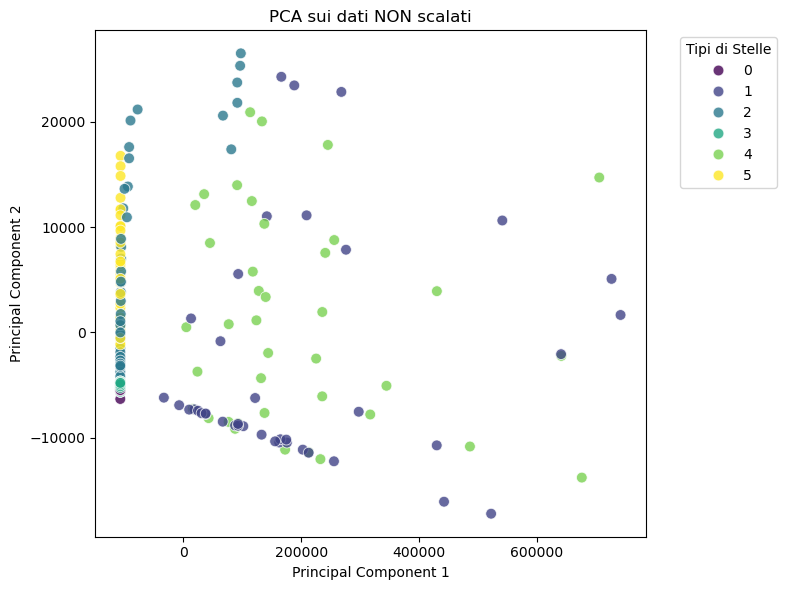

In [161]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=transf_data[:, 0], y=transf_data[:, 1], hue=df_stars['Star type'],palette='viridis',alpha=0.8,s=60)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA sui dati NON scalati')
plt.legend(title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Primo tentativo con dati standardizzati e solver=randomizer \
Provato sia 2 che 4 componenti, stesso contenuto di info presente nella prima componente 99.7%

In [167]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # da dividere per la varianza
X_scaled = scaler.fit_transform(X) # X should be put in log scale

pca_scaled = PCA(n_components=2, svd_solver='randomized')
transf_scaled_data = pca_scaled.fit_transform(X_scaled)

eigenvectors = pca_scaled.components_                      
variance = pca_scaled.explained_variance_
variance_percent = pca_scaled.explained_variance_ratio_ 
print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(variance_percent))

     Temperature (K)  Luminosity(L/Lo)  Radius(R/Ro)  Absolute magnitude(Mv)
0               3068          0.002400        0.1700                   16.12
1               3042          0.000500        0.1542                   16.60
2               2600          0.000300        0.1020                   18.70
3               2800          0.000200        0.1600                   16.65
4               1939          0.000138        0.1030                   20.06
..               ...               ...           ...                     ...
235            38940     374830.000000     1356.0000                   -9.93
236            30839     834042.000000     1194.0000                  -10.63
237             8829     537493.000000     1423.0000                  -10.73
238             9235     404940.000000     1112.0000                  -11.23
239            37882     294903.000000     1783.0000                   -7.80

[240 rows x 4 columns]
Expained fractional variance of data encapsulated in

In [163]:
pca995 = PCA(n_components=0.995)
pca995.fit(X_scaled)
print("{:d} features are needed to explain 99.5% of the variance".format(pca995.n_components_))

4 features are needed to explain 99.5% of the variance


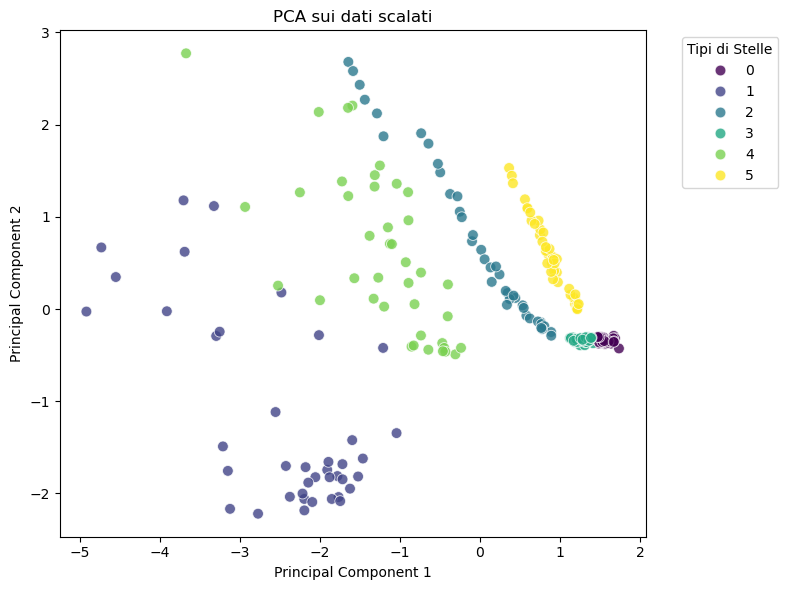

In [164]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=transf_scaled_data[:, 0], y=transf_scaled_data[:, 1], hue=df_stars['Star type'],palette='viridis',alpha=0.8,s=60)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA sui dati scalati')

plt.legend(title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## NonLinear dimensionality reduction

List of possible non linear dim reduction alogorithms:
* t-distributed Stochastic Neighbor Embedding (t-SNE)
* locally linear embedding (LLE)
* isometric mapping (IsoMap)

### LLE and IsoMap

* LLE works on preserving the local geometry of each point, computing the projection of neighbours (through wights) in the tangent space of each point (W).\
 Build the embedded space keeping the information in W  to preserve the local geometry

* IsoMap seeks to find a lower dimensional embedding of the data marix that maintains the geodesic distances between all points. Rather than using Euclidean distances between points, IsoMap actually approximates geodesic curves that lie in the embedded manifold, then computes the distances between each point in the data set along these geodesics.

### t-SNE

* Measure similiraty in the original space in terms of probability, using a multivariate gaussian at each point, measure all neighbourghs similarity. Similarity matrix is a measure of the local structure.
* In a lower dim space, measure similarity using t-student instead of gaussian, compute again a similarity matrix.
* Find the best trasformation from high to low dim space by minimizing differences between the two matrix (Kullback-Liebler Divergence)


In [165]:
# t-SNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,learning_rate=10)

X_tsne = tsne.fit_transform(X)
X_scaled_tsne = tsne.fit_transform(X_scaled)

fit_quality = tsne.kl_divergence_       
# measure of the amount of loss information
print(fit_quality)

0.12319760024547577


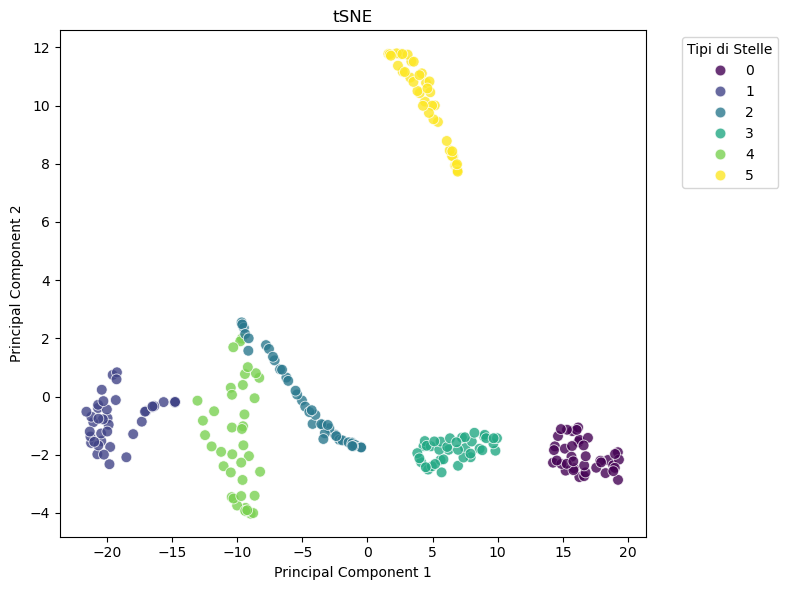

In [166]:
plt.figure(figsize=(8, 6))
# sns.scatterplot fa il lavoro di plt.scatter + plt.legend automaticamente
sns.scatterplot(x=X_scaled_tsne[:, 0], y=X_scaled_tsne[:, 1], hue=df_stars['Star type'],palette='viridis',alpha=0.8,s=60)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('tSNE')

# Spostiamo la legenda fuori dal grafico per non coprire i punti
plt.legend(title="Tipi di Stelle", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()